# Setup

In [269]:
%run notebook_setup.py

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import polars as pl
import pandas as pd
import logging
import gc
import random

import matplotlib.pyplot as plt
import seaborn as sns

from src.config.dir_config import OUTPUT_PATH_DEMAND_SUMMARY
from src.config.bigquery_config import CREDENTIALS_GBQ, PROJECT_ID_GBQ
from src.utils.read_data import read_data
from src.utils.setup_logging import setup_logging
from src.utils.create_week_date import add_week_start_date
from src.utils.export_as_excel import export_dataframes_as_tables


import logging

setup_logging()

Now you can import modules from the project root: /bi/workspace/Projects/Forecast/forecast


In [270]:
# Tus funciones (corrigiendo .round)
def calc_wape(total_error_abs, total_sales):
    return round(total_error_abs / total_sales, 4) if total_sales != 0 else np.nan

def calc_bias(total_error, total_sales):
    return round(total_error / total_sales, 4) if total_sales != 0 else np.nan

def calc_mae(error_abs):
    if len(error_abs) == 0:
        return np.nan
    return round(np.mean(error_abs), 4)

def calc_rmse(error):
    if len(error) == 0:
        return np.nan
    return round(np.sqrt(np.mean(np.square(error))), 4)

# Load data

In [271]:
data_all = pd.read_parquet('../sandbox/data_genex_venta_transfer.parquet')

In [272]:
demand_summary = pd.read_parquet('../sandbox/demand_summary.parquet')

# Forecast Tricot

In [273]:
data_all['forecast_tricot'] = (data_all['vta_promedio'] * data_all['factor'] * data_all['semana_vta']).fillna(0).round(0).astype('UInt16')

data_all['error'] = data_all['forecast_tricot'] - data_all['real_sales']
data_all['error_abs'] = data_all['error'].abs()

# Explorar error actual

In [274]:
cond1 = data_all["can_final"] > 0 # Que saliera repo
cond2 = data_all["repo_x_dda"] > 0 # Que hubiera repo x dda calculada
cond3 = data_all["repo_x_dda"] >= data_all["repo_x_ume"] # Que la repo sea por demanda

data_repo_x_dda = data_all.loc[cond1 & cond2 & cond3].copy()

In [275]:
tricot_df = data_repo_x_dda.copy()

tricot_df = tricot_df[['id','cod_sucursal','nombre_sucursal','cod_producto','nombre_depto','nombre_linea','cod_talla','nom_talla','week_number','date',
                             'vta_promedio','factor','semana_vta',
                             'repo_x_dda','repo_x_ume','can_final',
                             'real_sales','forecast_tricot', 'error','error_abs']]

## a) Error total

In [276]:
wape = calc_wape(tricot_df['error_abs'].sum(), tricot_df['real_sales'].sum())
bias = calc_bias(tricot_df['error'].sum(), tricot_df['real_sales'].sum())
mae = calc_mae(tricot_df['error_abs'])
rmse = calc_rmse(tricot_df['error'])

In [277]:
print("WAPE:", wape)
print("Bias:", bias)
print("MAE:", mae)
print("RMSE:", rmse)

WAPE: 1.7309
Bias: 1.5905
MAE: 11.4741
RMSE: 47.6163


## b) Error por semana

In [278]:
tricot_df_weekly = tricot_df.groupby(['date'] ).apply(
    lambda g: pd.Series({
        'can_final': g['can_final'].sum(),
        'wape': calc_wape(g['error_abs'].sum(), g['real_sales'].sum()),
        'bias': calc_bias(g['error'].sum(), g['real_sales'].sum()),
        'mae': calc_mae(g['error_abs']),
        'rmse': calc_rmse(g['error']),
        'vta_promedio': g['vta_promedio'].mean(),
        'factor': g['factor'].mean(),
        'semana_vta': g['semana_vta'].mean(),
    })
).reset_index()

tricot_df_weekly['prop_can_final'] = (tricot_df_weekly['can_final'] / tricot_df_weekly['can_final'].sum()).round(4)

tricot_df_weekly = tricot_df_weekly.query('prop_can_final >= 0.005').reset_index(drop=True)

tricot_df_weekly.to_excel('../sandbox/tricot_df_weekly.xlsx')
tricot_df_weekly

/tmp/ipykernel_3129688/1852582930.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tricot_df_weekly = tricot_df.groupby(['date'] ).apply(


,date,can_final,wape,bias,mae,rmse,vta_promedio,factor,semana_vta,prop_can_final
0,2025-01-06,11706.0,1.7476,1.6623,6.7203,8.6929,1.710267,1.000000,6.000000,0.0065
1,2025-01-13,11074.0,1.2069,1.0366,4.9836,6.7021,1.401715,1.000000,6.000000,0.0061
2,2025-01-20,57240.0,1.0441,0.8768,6.9035,9.5559,1.370940,1.132354,8.000000,0.0316
3,2025-01-27,112696.0,1.1092,0.9783,6.3607,9.1491,1.229205,1.161729,8.000000,0.0623
4,2025-02-03,101586.0,0.9276,0.7739,5.5198,7.8003,1.150767,1.148409,8.000000,0.0561
5,2025-02-10,35029.0,1.1420,0.9837,6.5054,9.3157,1.004696,1.445153,8.000000,0.0194
6,2025-02-17,74005.0,1.3220,1.2135,7.1712,10.1679,1.048179,1.520178,8.000000,0.0409
7,2025-02-24,78288.0,1.1859,1.0821,6.8969,9.4912,1.033155,1.524841,8.000000,0.0433
8,2025-03-03,67006.0,1.1204,0.9849,6.1926,8.8436,1.044106,1.373565,8.000000,0.0370
9,2025-03-10,72647.0,1.1690,1.0667,6.6572,9.6415,1.093632,1.407427,8.000000,0.0401


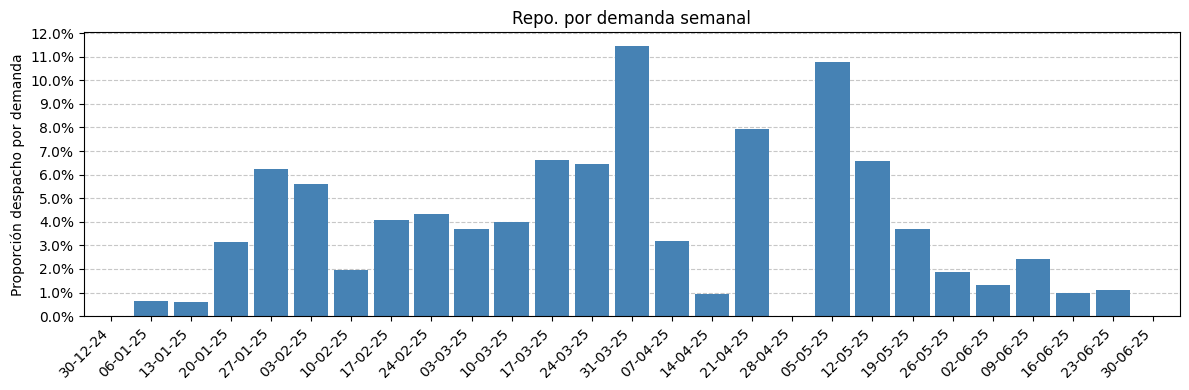

In [279]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker


plt.figure(figsize=(12, 4))
plt.bar(tricot_df_weekly['date'],
        tricot_df_weekly['prop_can_final'],
        width=pd.Timedelta(days=6),   # ancho de la barra ≈ 1 semana
        align='center',
        color='steelblue',
        zorder=2)

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.01))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.ylabel("Proporción despacho por demanda")

plt.ylim(bottom=0)
plt.xticks(rotation=45, ha='right')
plt.title("Repo. por demanda semanal")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)
plt.show()

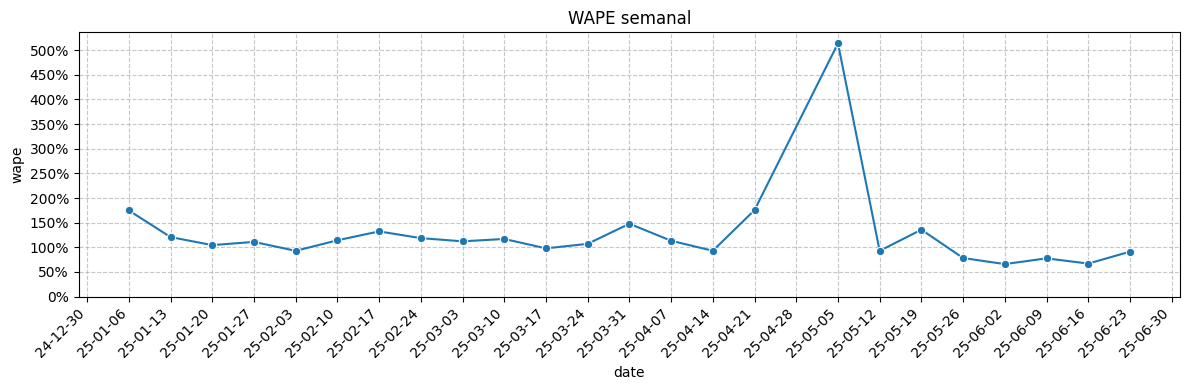

,date,can_final,wape,bias,mae,rmse,vta_promedio,factor,semana_vta,prop_can_final
0,2025-01-06,11706.0,1.7476,1.6623,6.7203,8.6929,1.710267,1.000000,6.000000,0.0065
1,2025-01-13,11074.0,1.2069,1.0366,4.9836,6.7021,1.401715,1.000000,6.000000,0.0061
2,2025-01-20,57240.0,1.0441,0.8768,6.9035,9.5559,1.370940,1.132354,8.000000,0.0316
3,2025-01-27,112696.0,1.1092,0.9783,6.3607,9.1491,1.229205,1.161729,8.000000,0.0623
4,2025-02-03,101586.0,0.9276,0.7739,5.5198,7.8003,1.150767,1.148409,8.000000,0.0561
5,2025-02-10,35029.0,1.1420,0.9837,6.5054,9.3157,1.004696,1.445153,8.000000,0.0194
6,2025-02-17,74005.0,1.3220,1.2135,7.1712,10.1679,1.048179,1.520178,8.000000,0.0409
7,2025-02-24,78288.0,1.1859,1.0821,6.8969,9.4912,1.033155,1.524841,8.000000,0.0433
8,2025-03-03,67006.0,1.1204,0.9849,6.1926,8.8436,1.044106,1.373565,8.000000,0.0370
9,2025-03-10,72647.0,1.1690,1.0667,6.6572,9.6415,1.093632,1.407427,8.000000,0.0401


In [280]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

plt.figure(figsize=(12, 4))

sns.lineplot(x='date', y='wape', data=tricot_df_weekly,
             marker = 'o')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d'))
plt.ylim(bottom=0)
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.5))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))


plt.title("WAPE semanal")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
display(tricot_df_weekly)

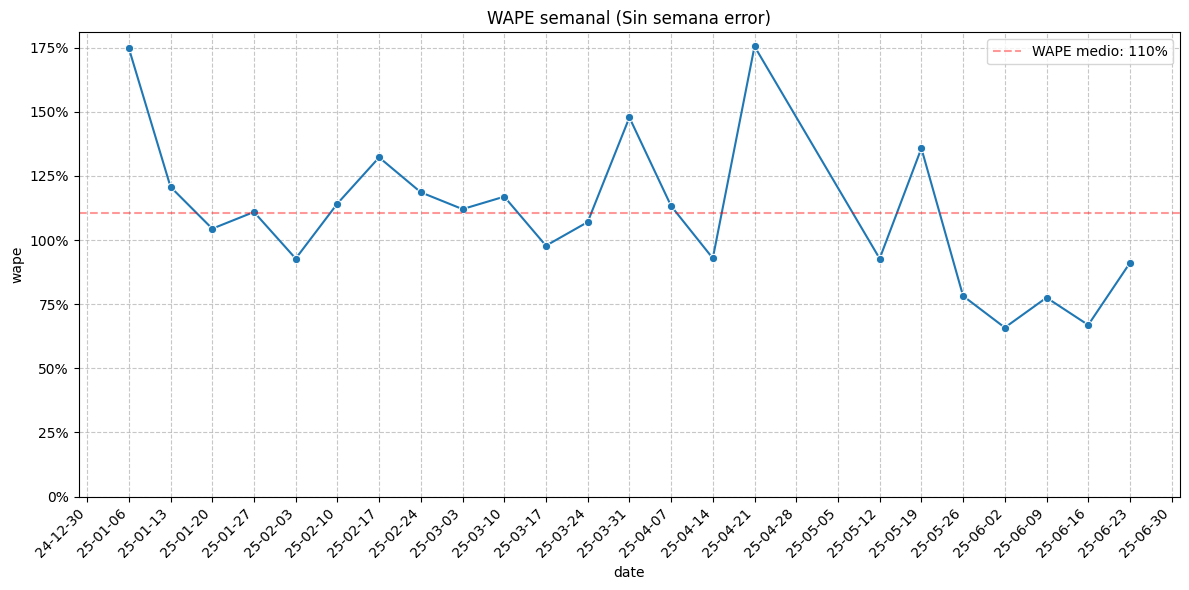

In [281]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

plt.figure(figsize=(12, 6))

sns.lineplot(x='date', y='wape', data=tricot_df_weekly.drop(index=16),
             marker = 'o')

mean_wape = tricot_df_weekly.drop(index=16)['wape'].mean()
plt.axhline(y=mean_wape, color='red', linestyle='--', alpha= 0.4, label = f'WAPE medio: {mean_wape:.0%}')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d'))
plt.ylim(bottom=0)
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.25))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.title("WAPE semanal (Sin semana error)")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="")
plt.show()

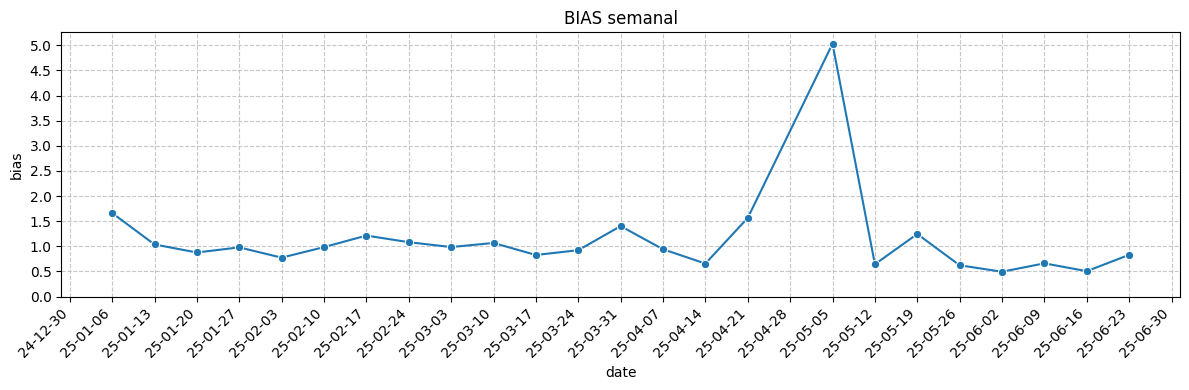

In [282]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 4))
sns.lineplot(x='date', y='bias', data=tricot_df_weekly,
             marker = 'o')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d'))
plt.ylim(bottom=0)
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.5))

plt.title("BIAS semanal")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

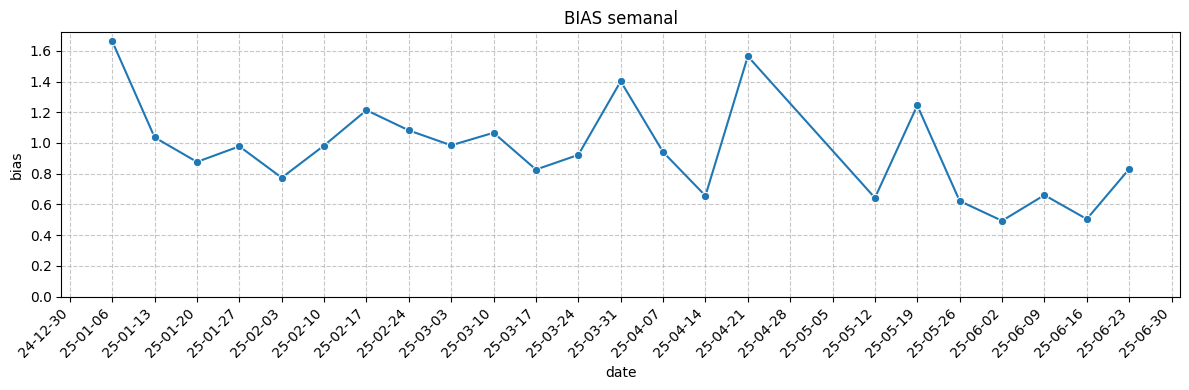

In [283]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 4))
sns.lineplot(x='date', y='bias', data=tricot_df_weekly.drop(index=16),
             marker = 'o')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d'))
plt.ylim(bottom=0)
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.2))

plt.title("BIAS semanal")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

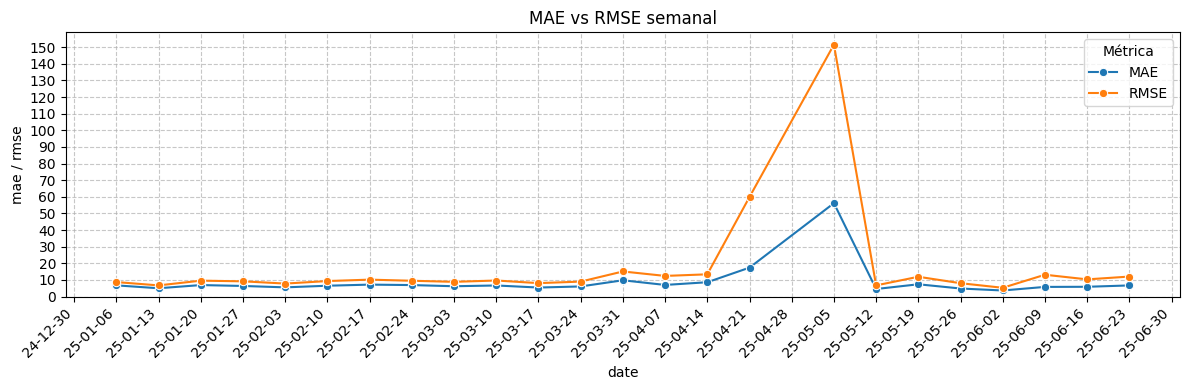

In [284]:
plt.figure(figsize=(12, 4))

sns.lineplot(x='date', y='mae', data=tricot_df_weekly,
             marker='o', label='MAE')

sns.lineplot(x='date', y='rmse', data=tricot_df_weekly,
             marker='o', label='RMSE')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d'))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(10))
plt.ylim(bottom=0)
plt.xticks(rotation=45, ha='right')
plt.ylabel('mae / rmse')

plt.title("MAE vs RMSE semanal")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

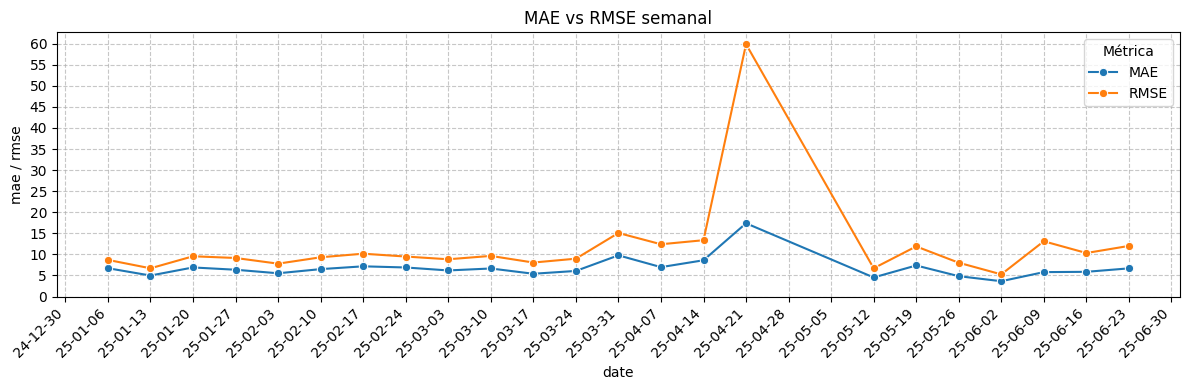

In [285]:
plt.figure(figsize=(12, 4))

sns.lineplot(x='date', y='mae', data=tricot_df_weekly.drop(index=16),
             marker='o', label='MAE')

sns.lineplot(x='date', y='rmse', data=tricot_df_weekly.drop(index=16),
             marker='o', label='RMSE')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d'))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(5))
plt.ylim(bottom=0)
plt.xticks(rotation=45, ha='right')
plt.ylabel('mae / rmse')

plt.title("MAE vs RMSE semanal")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

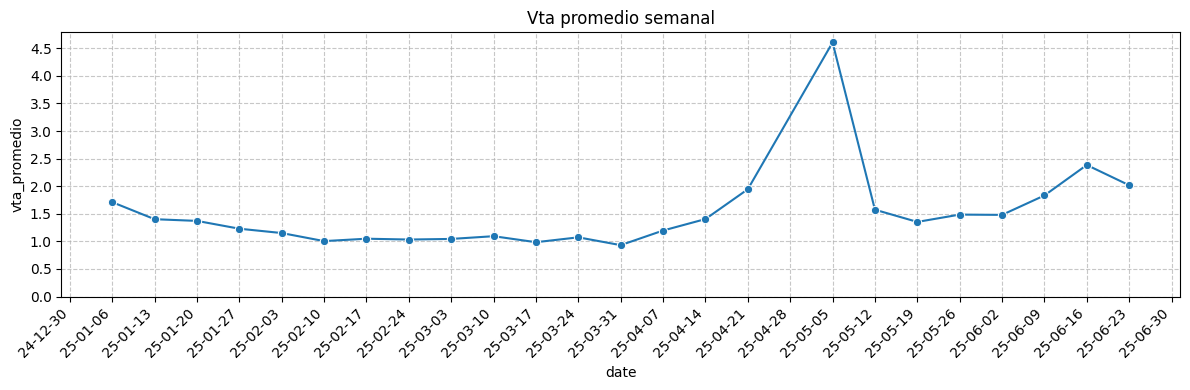

In [286]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 4))
sns.lineplot(x='date', y='vta_promedio', data=tricot_df_weekly,
             marker = 'o')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d'))
plt.ylim(bottom=0)
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.5))

plt.title("Vta promedio semanal")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

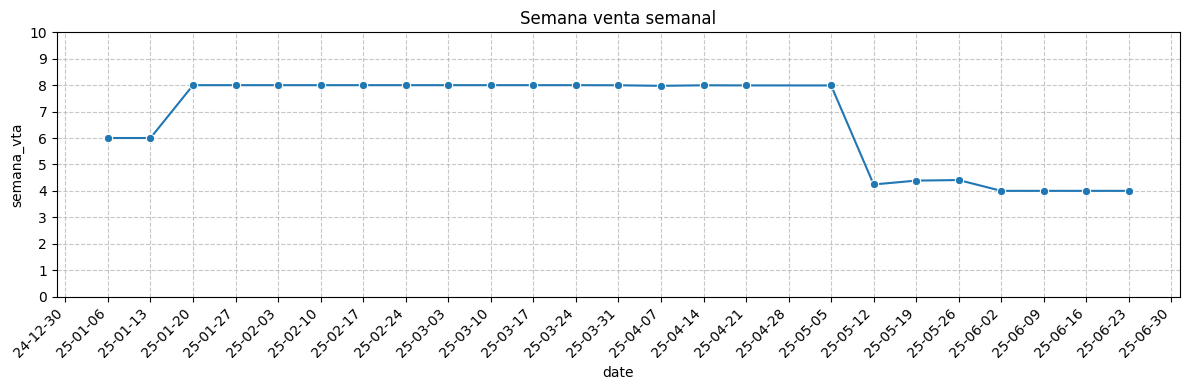

In [287]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 4))
sns.lineplot(x='date', y='semana_vta', data=tricot_df_weekly,
             marker = 'o')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d'))
plt.ylim(bottom=0, top=10)
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title("Semana venta semanal")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

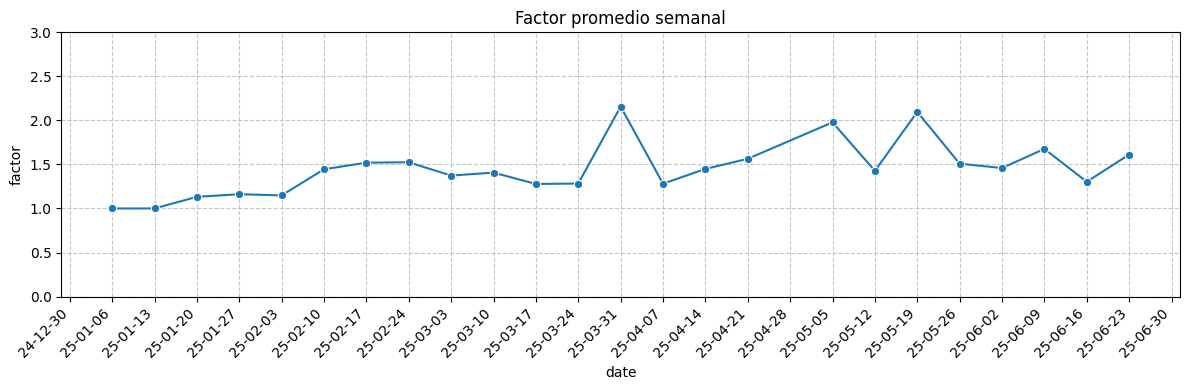

In [288]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 4))
sns.lineplot(x='date', y='factor', data=tricot_df_weekly,
             marker = 'o')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d'))
plt.ylim(bottom=0, top=3)
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.5))

plt.title("Factor promedio semanal")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## c) Error por semana en sucursal

In [289]:
tricot_df_week_number = tricot_df.groupby('week_number', ).apply(
    lambda g: pd.Series({
        'can_final': g['can_final'].sum(),
        'wape': calc_wape(g['error_abs'].sum(), g['real_sales'].sum()),
        'bias': calc_bias(g['error'].sum(), g['real_sales'].sum()),
        'mae': calc_mae(g['error_abs']),
        'rmse': calc_rmse(g['error'])
    })
).reset_index()

tricot_df_week_number['prop_can_final'] = (tricot_df_week_number['can_final'] / tricot_df_week_number['can_final'].sum()).round(4)

tricot_df_week_number = tricot_df_week_number.query('prop_can_final >= 0.005').reset_index(drop=True)

tricot_df_week_number

/tmp/ipykernel_3129688/784890084.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tricot_df_week_number = tricot_df.groupby('week_number', ).apply(


,week_number,can_final,wape,bias,mae,rmse,prop_can_final
0,2,324071.0,1.1539,0.9963,8.1762,17.4154,0.1791
1,3,389451.0,1.5413,1.4074,9.3871,32.1548,0.2152
2,4,210311.0,1.6134,1.4679,9.1715,43.5121,0.1162
3,5,131913.0,1.5459,1.3598,9.3970,36.9724,0.0729
4,6,187743.0,1.6499,1.5087,10.4879,49.8213,0.1037
5,7,158844.0,2.1145,1.9799,15.5048,67.6821,0.0878
6,8,114948.0,1.5894,1.4367,10.4452,36.3988,0.0635
7,9,78811.0,1.6628,1.5224,12.0138,47.9406,0.0436
8,10,63916.0,2.0359,1.9135,17.6989,84.0550,0.0353
9,11,53729.0,2.2541,2.1438,19.8932,71.5979,0.0297


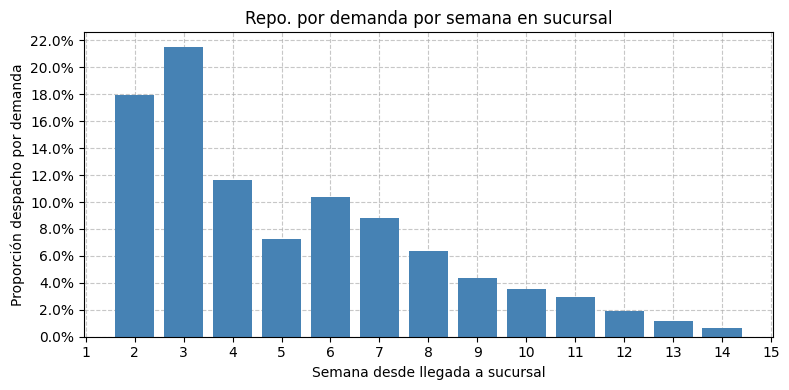

In [290]:
import matplotlib.ticker as mticker

plt.figure(figsize=(8, 4))

plt.bar(tricot_df_week_number['week_number'],
        tricot_df_week_number['prop_can_final'],
        align='center',
        color='steelblue',
        zorder=2)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.02))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.ylabel("Proporción despacho por demanda")
plt.xlabel("Semana desde llegada a sucursal")

plt.title("Repo. por demanda por semana en sucursal")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

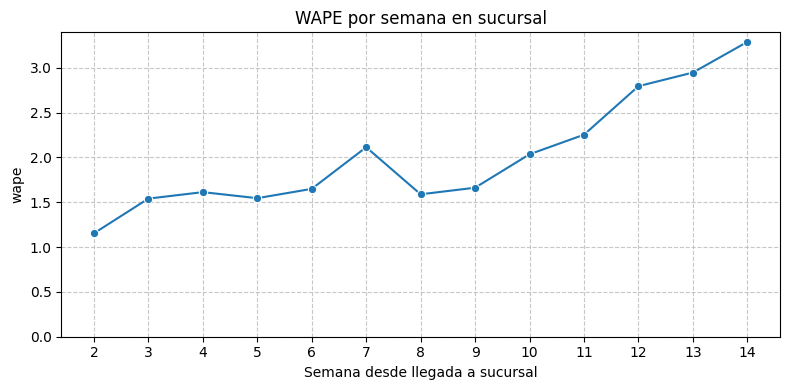

In [291]:
plt.figure(figsize=(8, 4))

sns.lineplot(x='week_number', y='wape', data=tricot_df_week_number,
             marker='o')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.ylim(bottom=0)
plt.xlabel("Semana desde llegada a sucursal")

plt.title("WAPE por semana en sucursal")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

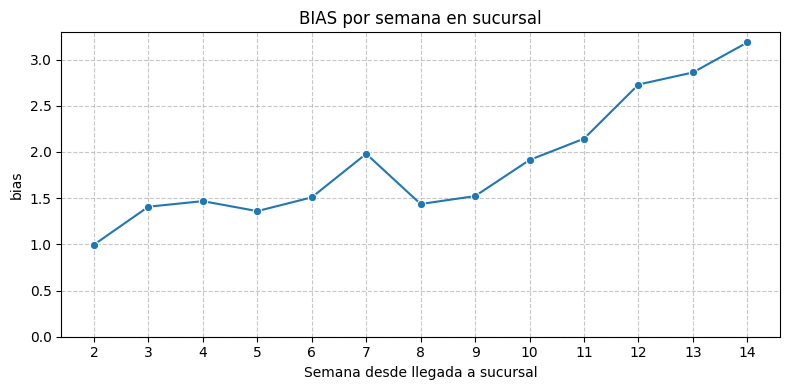

In [292]:
plt.figure(figsize=(8, 4))

sns.lineplot(x='week_number', y='bias', data=tricot_df_week_number,
             marker='o')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.ylim(bottom=0)
plt.xlabel("Semana desde llegada a sucursal")

plt.title("BIAS por semana en sucursal")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

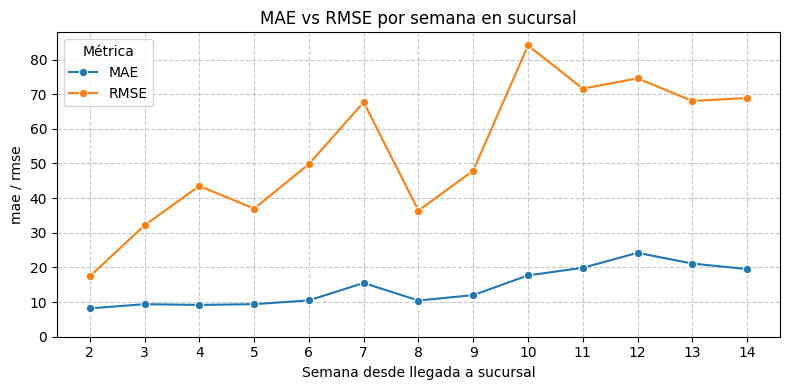

In [293]:
plt.figure(figsize=(8, 4))

sns.lineplot(x='week_number', y='mae', data=tricot_df_week_number,
             marker='o', label='MAE')

sns.lineplot(x='week_number', y='rmse', data=tricot_df_week_number,
             marker='o', label='RMSE')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.ylim(bottom=0)
plt.ylabel('mae / rmse')
plt.xlabel("Semana desde llegada a sucursal")

plt.title("MAE vs RMSE por semana en sucursal")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

## d) Por depto

In [294]:
tricot_df_depto = tricot_df.groupby(['nombre_depto','nombre_linea','date'], ).apply(
    lambda g: pd.Series({
        'can_final': g['can_final'].sum(),
        'wape': calc_wape(g['error_abs'].sum(), g['real_sales'].sum()),
        'bias': calc_bias(g['error'].sum(), g['real_sales'].sum()),
        'mae': calc_mae(g['error_abs']),
        'rmse': calc_rmse(g['error'])
    })
).reset_index()

tricot_df_depto['prop_can_final'] = (tricot_df_depto['can_final'] / tricot_df_depto.groupby(['nombre_depto','nombre_linea',])['can_final'].transform('sum')).round(4)

tricot_df_depto = tricot_df_depto.query('prop_can_final >= 0.005').reset_index(drop=True)

/tmp/ipykernel_3129688/1398993689.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tricot_df_depto = tricot_df.groupby(['nombre_depto','nombre_linea','date'], ).apply(


In [295]:
tricot_df_depto.nlargest(10, 'prop_can_final')

,nombre_depto,nombre_linea,date,can_final,wape,bias,mae,rmse,prop_can_final
137,Accesorios,Regalos,2025-04-21,475.0,2.9765,2.6781,62.3803,122.1509,0.8467
9,Accesorios,Bananos,2025-03-31,341.0,2.2715,2.2715,17.8649,19.9845,0.7698
396,Formal hombres,Boxer,2025-03-31,6580.0,2.0194,2.0118,18.6195,29.2804,0.7482
514,Jeans juv hombre,Jeans,2025-01-27,69.0,18.5000,18.5000,21.1429,22.9845,0.7041
810,Juvenil mujer,Vestidos,2025-05-19,2597.0,4.1481,4.1199,4.1481,5.1386,0.6994
997,Ninas,Pijamas,2025-05-12,4263.0,2.1598,2.0849,6.4727,8.8472,0.6842
517,Juvenil hombres,Camisas manga corta,2025-01-27,356.0,8.0390,8.0390,18.7576,20.2529,0.6654
1177,Sport hombres,Lanas,2025-05-05,2053.0,3.3006,3.2245,34.5193,85.1659,0.6631
945,Lenceria,Regalos,2025-04-21,1387.0,0.1506,0.0834,4.6042,7.3923,0.6359
3,Accesorios,Accesorios pelo,2025-05-05,1399.0,3.0648,3.0600,19.8974,23.9195,0.6296


In [296]:
example_category = tricot_df_depto.query('nombre_depto == "Formal hombres" and nombre_linea == "Boxer"')

# Ejemplo

In [297]:
cod_producto = 680279
cod_talla = 105

data_sample = tricot_df[tricot_df['cod_producto'] == cod_producto].copy()
data_sample = data_sample[data_sample['cod_talla'] == cod_talla].copy()

demand_sample = demand_summary[demand_summary['cod_producto'] == cod_producto]
demand_sample = demand_sample[demand_sample['cod_talla'] == cod_talla]

In [298]:
data_sample.to_excel("../sandbox/data_sample.xlsx", index=False)

In [299]:
demand_sample.groupby('available_inventory_weeks').agg(
    sucursales = ('cod_sucursal', 'nunique'),
    predist_mean = ('PREDISTRIBUIDA', 'mean'),
    repo_auto_mean = ('REPOSICION AUTOMATIC', 'mean'),
    carga_man_mean = ('CARGA MANUAL', 'mean'),
    otras_mean = ('OTRAS', 'mean')
).round(1)

,sucursales,predist_mean,repo_auto_mean,carga_man_mean,otras_mean
available_inventory_weeks,,,,,
2,1,4.0,0.0,0.0,0.0
3,2,4.0,0.0,0.0,0.0
4,3,4.0,0.0,0.0,0.0
5,3,5.3,0.0,0.0,0.0
6,4,4.0,0.0,0.0,0.0
7,1,4.0,0.0,0.0,0.0
8,8,4.5,0.0,0.0,0.0
9,4,6.0,0.0,0.0,0.0
10,5,5.6,0.0,0.0,0.0
